# ARCH/GARCH modelling and volatility analysis

In this notebook, we,

- learn about volatility and volatility modelling
- learn how to analyse volatility using ARCH and GARCH models in Python
- obtain and analyse S&P500 dataset from St. Louis FRED

This notebook draws on,

- [GARCH Models in Python](https://app.datacamp.com/learn/courses/garch-models-in-python) (DataCamp)
- [Master Volatility with ARCH & GARCH Models](https://youtu.be/iImtlBRcczA?si=7AtMWY6rr-3jmSq_) (Roman Paolucci, YouTube)
- Neusser, K. (2016) 'Models of Volatility' in *Time Series Econometrics*, Springer.

## Objectives

### Model estimation

- estimated parameters help us understand volatility dynamics, viz. persistence ($\alpha+\beta$), long-run variance ($\omega/(1-\alpha-\beta)$), stationarity
- conditional variance $\hat{\sigma}_t^2$ captures volatility clustering
- standardised residuals $z_t$ are a diagnostic output. By assumption, $z_t \overset{\text{i.i.d.}}{\sim} \mathcal{N}(0,1)$

### Forecasting

- variance is used in variance at risk / risk managment, option pricing, portfolio rebalancing
- $\hat{\mu}$ is constant in a constant-mean model
- GARCH variance forecasts mean-revert to the long-run variance $\frac{\omega}{(1-\alpha-\beta)}$ as $h \to \infty$

## Fundamentals of volatility

Returns as a percentage:
$$\text{(return)}=\frac{P_1-P_0}{P_0}$$

Sample mean return:
$$\text{(mean)}=\frac{\sum_{i=1}^n \text{(return)}_i}{n}$$

Sample standard deviation:
$$\text{(volatility)}=\sqrt{\frac{\sum_{i=1}^n (\text{(return)}_i-\text{(mean)})^2}{n-1}}=\sqrt{\text{(variance)}}$$

Monthly volatility:
$$\sigma_{\text{(monthly)}}=\sqrt{21}\sigma_{\text{(daily)}}$$

Annual volatility:
$$\sigma_{\text{(annual)}}=\sqrt{252}\sigma_{\text{(daily)}}$$

## Fundamentals of ARCH/GARCH modelling

Expected return:
$$\mu_t = \mathbb{E}[r_t \mid I_{t-1}]$$

Mean equation:
$$\begin{align*}
r_t&=\mu_t+\epsilon_t \\
&=\ln{(P_t)}-\ln{(P_{t-1})}
\end{align*}$$

Expected volatility:
$$\sigma_t^2=\mathbb{E}[(r_t-\mu_t)^2 \mid I_{t-1}]$$

Residuals:
$$\begin{align*}
\epsilon_t &= \sigma_t z_t, \quad z_t \overset{\text{i.i.d.}}{\sim} (0,1) \\
&= r_t - \mu_t
\end{align*}$$

Standardised residuals:
$$z_t=\frac{\epsilon_t}{\sigma_t}$$

ARCH(p) with the stationarity condition:
$$\sigma_t^2=\omega+\sum_{i=1}^p \alpha_i\epsilon_{t-i}^2, \qquad \sum_{i=1}^p \alpha_i < 1$$

GARCH(p,q) with the stationarity condition:
$$\sigma_t^2=\omega+\sum_{i=1}^p \alpha_i\epsilon_{t-i}^2 + \sum_{j=1}^q\beta_j\sigma_{t-j}^2, \qquad \sum_{i=1}^p \alpha_i + \sum_{i=1}^q \beta_j < 1$$

### GJR-GARCH/EGARCH

GJR-GARCH and EGARCH model asymmetric shocks. 

In [90]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

import requests as rq

from scipy.stats import iqr, quantile, norm, shapiro, jarque_bera, chi2
from statsmodels.graphics.gofplots import qqplot
from arch import arch_model

## Helpers

In [84]:
# Convert daily volatility to annual
def annual_vol(col):
    return np.sqrt(252) * np.std(col, ddof = 1)

# Binwidth
def freedman_diaconis(vec):
    vec = np.asarray(vec)
    return 2 * iqr(vec) * len(vec) ** (-1 / 3)

def fd_bins(vec):
    vec = np.asarray(vec)
    return int((np.max(vec) - np.min(vec)) / freedman_diaconis(vec))

# Investigate a date col
def investigate_dates(date_col, freq = "D"):
    dates = pd.to_datetime(date_col)

    first_date = dates.min()
    last_date = dates.max()

    full_range = pd.date_range(first_date, last_date, freq = freq)

    missing = full_range.difference(dates)
    duplicates = dates[dates.duplicated()]
    
    gaps = dates.sort_values().diff().value_counts()

    return {
        "start": first_date,
        "end": last_date,
        "expected_count": len(full_range),
        "actual_count": len(dates),
        "missing_count": len(missing),
        "missing_dates": missing.tolist(),
        "duplicate_count": duplicates.shape[0],
        "duplicate_dates": duplicates.tolist(),
        "gap_distribution": gaps
    }

# Convert daily volatility to monthly
def monthly_vol(col):
    return np.sqrt(21) * np.std(col, ddof = 1)

# Read in a text file
def read_txt(path):
    with open(path,"r") as f:
        string = f.read()
    return string

# Read a FRED API into a df
def request_fred_df(base_url, endpoint, parameters):
    res = rq.get(base_url + endpoint, params = parameters)
    
    if res.status_code == 200:
        res_data = res.json()
        return pd.DataFrame(res_data["observations"])
    else:
        print("Failed to retrieve data. Status code:", res.status_code)
        return None

## S&P500 data

In [27]:
# API key
path = "C:/data/fred_api_key.txt"
api_key = read_txt(path)

# Base URL
base_url = "https://api.stlouisfed.org/fred/"

# Assign endpoint
endpoint = "series/observations"

# Assign parameters
# https://fred.stlouisfed.org/series/SP500
series_id = "SP500"
start_date = "2000-01-01"
end_date = "2026-03-19"
#ts_frequency
#ts_units

parameters = {
    'series_id': series_id,
    'api_key': api_key,
    'file_type': 'json',
    'observation_start': start_date,
    'observation_end': end_date,
    # 'frequency': ts_frequency
    # 'units': ts_units
}

In [28]:
# Make request to FRED API
snp = request_fred_df(base_url, endpoint, parameters)

In [29]:
# Format the data
snp = snp[["date", "value"]]
snp["date"] = pd.to_datetime(snp["date"])
snp["value"] = pd.to_numeric(snp["value"], errors = "coerce")

snp.head()

,date,value
0,2016-03-21,2051.60
1,2016-03-22,2049.80
2,2016-03-23,2036.71
3,2016-03-24,2035.94
4,2016-03-25,NaN


In [30]:
# Investigate NaNs
pd.DataFrame({
    "col": snp.columns,
    "value": [snp[c].isnull().sum() for c in snp.columns]
})

,col,value
0,date,0
1,value,95


In [31]:
# Investigate duplicates
snp["date"].duplicated().sum()

np.int64(0)

In [32]:
# Investigate discontinuities
dt_log = investigate_dates(snp.date)
dt_log["gap_distribution"]

date
1 days    2087
3 days     521
Name: count, dtype: int64

In [33]:
dt_log["missing_dates"][:10]

[Timestamp('2016-03-26 00:00:00'),
 Timestamp('2016-03-27 00:00:00'),
 Timestamp('2016-04-02 00:00:00'),
 Timestamp('2016-04-03 00:00:00'),
 Timestamp('2016-04-09 00:00:00'),
 Timestamp('2016-04-10 00:00:00'),
 Timestamp('2016-04-16 00:00:00'),
 Timestamp('2016-04-17 00:00:00'),
 Timestamp('2016-04-23 00:00:00'),
 Timestamp('2016-04-24 00:00:00')]

These are weekends.

In [34]:
snp[snp["value"].isnull()].head(10)

,date,value
4,2016-03-25,NaN
50,2016-05-30,NaN
75,2016-07-04,NaN
120,2016-09-05,NaN
178,2016-11-24,NaN
200,2016-12-26,NaN
205,2017-01-02,NaN
215,2017-01-16,NaN
240,2017-02-20,NaN
279,2017-04-14,NaN


And these are bank holidays.

## Returns and volatility

In [35]:
# Compute the returns
snp["pct_return"] = 100 * snp["value"].pct_change(fill_method = None)
snp["log_return"] = np.log(snp["value"]) - np.log(snp["value"].shift(1))

snp.head()

,date,value,pct_return,log_return
0,2016-03-21,2051.60,NaN,NaN
1,2016-03-22,2049.80,-0.087736,-0.000878
2,2016-03-23,2036.71,-0.638599,-0.006406
3,2016-03-24,2035.94,-0.037806,-0.000378
4,2016-03-25,NaN,NaN,NaN


In [36]:
# Monthly volatility
df = snp.copy()

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df.groupby(["year", "month"])["log_return"].agg(monthly_vol = lambda c: np.sqrt(21) * np.std(c, ddof = 1)).head()

monthly_vol
year month             
2016 3         0.024256
     4         0.029302
     5         0.032881
     6         0.053890
     7         0.019747

In [37]:
# Annual volatility
df.groupby("year")["log_return"].agg(annual_vol = lambda c: np.sqrt(252) * np.std(c, ddof = 1)).head()

,annual_vol
year,
2016,0.108983
2017,0.066229
2018,0.164500
2019,0.125300
2020,0.351092


## Custom function

Construct a custom function and simulate the ARCH/GARCH process.

In [38]:
# Define an ARCH(1)/GARCH(1,1) function
def simulate_GARCH(n, omega, alpha, beta = 0, mu = 0, burnin = 50):
    N = n + burnin
    z = np.random.normal(loc = 0, scale = 1, size = N)
    sigma2 = np.zeros(N)
    eps = np.zeros(N)
    y = np.zeros(N)
    
    sigma2[0] = omega / (1 - alpha - beta)
    eps[0] = np.sqrt(sigma2[0]) * z[0]
    y[0] = mu + eps[0]
    
    for t in range(1, N):
        sigma2[t] = omega + alpha * eps[t - 1]**2 + beta * sigma2[t - 1]
        eps[t] = np.sqrt(sigma2[t]) * z[t]
        y[t] = mu + eps[t]

    sigma2 = sigma2[burnin:]
    eps = eps[burnin:]
    y = y[burnin:]

    return (eps, sigma2, y)


ARCH(1)/GARCH(1,1) variance:



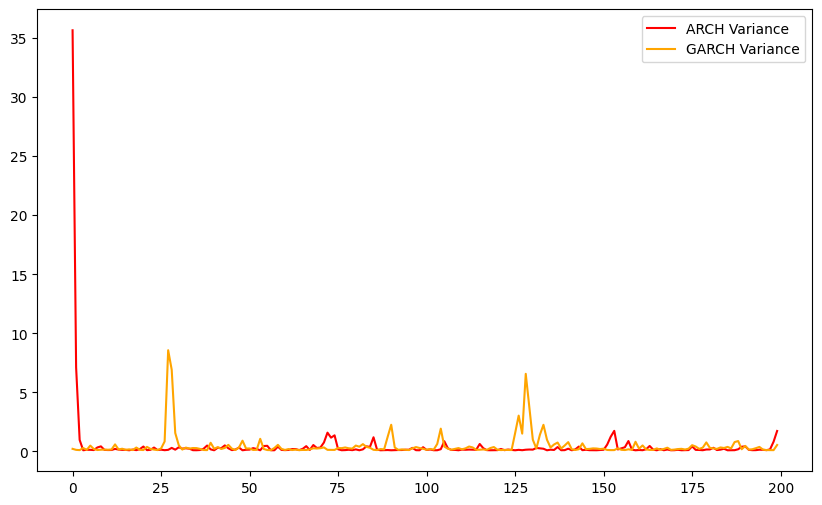

In [39]:
# Simulate a ARCH(1) series
arch_resid, arch_variance, model = simulate_GARCH(
    n = 200, 
    omega = 0.1, 
    alpha = 0.7
)

# Simulate a GARCH(1,1) series
garch_resid, garch_variance, model = simulate_GARCH(
    n = 200, 
    omega = 0.1, 
    alpha = 0.7, 
    beta = 0.1
)

plt.figure(figsize = (10, 6))
# Plot the ARCH variance
plt.plot(arch_variance, color = 'red', label = 'ARCH Variance')

# Plot the GARCH variance
plt.plot(garch_variance, color = 'orange', label = 'GARCH Variance')
plt.legend()

print("\nARCH(1)/GARCH(1,1) variance:\n")
plt.show()


GARCH(1,1) variance and residuals:



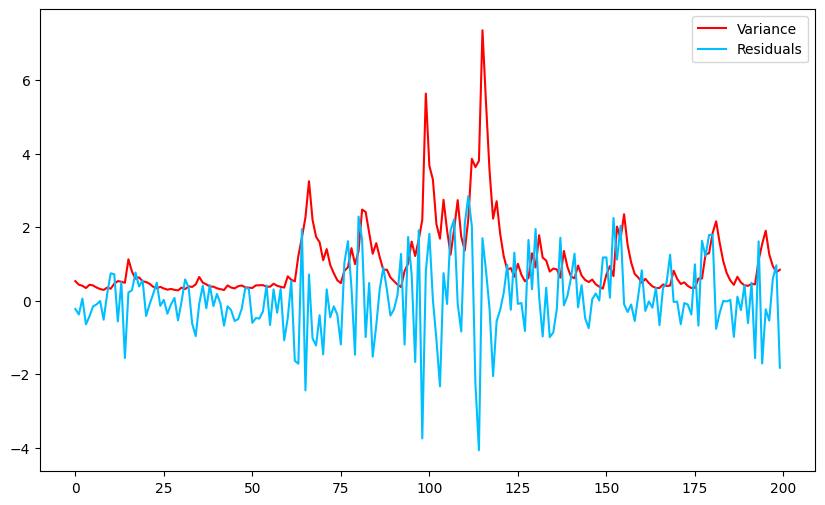

In [40]:
# Second simulated GARCH
sim_resid, sim_variance, model = simulate_GARCH(
    n = 200,  
    omega = 0.1,
    alpha = 0.3, 
    beta = 0.6
)

plt.figure(figsize = (10, 6))
plt.plot(sim_variance, color = 'red', label = 'Variance')
plt.plot(sim_resid, color = 'deepskyblue', label = 'Residuals')
plt.legend(loc='upper right')

print("\nGARCH(1,1) variance and residuals:\n")
plt.show()

## Canned routine

Explore the ARCH/GARCH routine on the S&P500 dataset.

``` Python
# arch_model parameters
mean = ["zero", "constant", "AR"]
vol = ["ARCH", "GARCH", "EGARCH"]
dist = ["normal", "t", "skewt"]
```

In [41]:
# Filter out NaNs and scale the log returns
snp_returns = snp["log_return"].dropna() * 100

### Normal model

#### Fit the model and extract results

In [ ]:
# Specify GARCH model assumptions
basic_gm = arch_model(snp_returns, p = 1, q = 1, mean = "constant", vol = "GARCH", dist = "normal")

# Fit the model
gm_result = basic_gm.fit(update_freq = 4)

# Display model fitting summary
print(gm_result.summary())

Iteration:      4,   Func. Count:     33,   Neg. LLF: 3282.50123533948
Iteration:      8,   Func. Count:     56,   Neg. LLF: 3085.2985155153765
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3085.293382640665
            Iterations: 11
            Function evaluations: 70
            Gradient evaluations: 11
                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3085.29
Distribution:                  Normal   AIC:                           6178.59
Method:            Maximum Likelihood   BIC:                           6201.75
                                        No. Observations:                 2418
Date:                Fri, Mar 20 2026   Df Residuals:                     2417
Time:          


Standardised residuals and standard deviation (normal model):



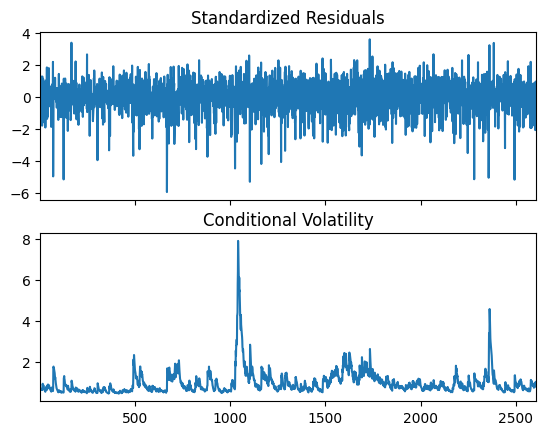

In [52]:
# Plot fitted results
gm_result.plot()

print("\nStandardised residuals and standard deviation (normal model):\n")
plt.show()

#### Extract the series

In [44]:
# Extract residuals
gm_residuals = gm_result.resid
#std_resid = gm_result.resid / gm_result.conditional_volatility
gm_std_resid = gm_result.std_resid

# Extract standard deviation series
gm_std_dev = gm_result.conditional_volatility

# Extract conditional variance series: sigma_t^2
gm_variance = gm_std_dev ** 2

# Fitted parameters
gm_params = gm_result.params

print("\nParameter estimates:\n")
print(gm_params)


Parameter estimates:

mu          0.087559
omega       0.037501
alpha[1]    0.181847
beta[1]     0.790800
Name: params, dtype: float64


In [45]:
# Check the ARCH (shock) and GARCH (persistence) terms for stationarity
print("\nIs the stationarity condition satisfied?\n")
gm_params["alpha[1]"] + gm_params["beta[1]"] < 1


Is the stationarity condition satisfied?



np.True_

#### Inspect residuals


Distribution of standardised residuals:



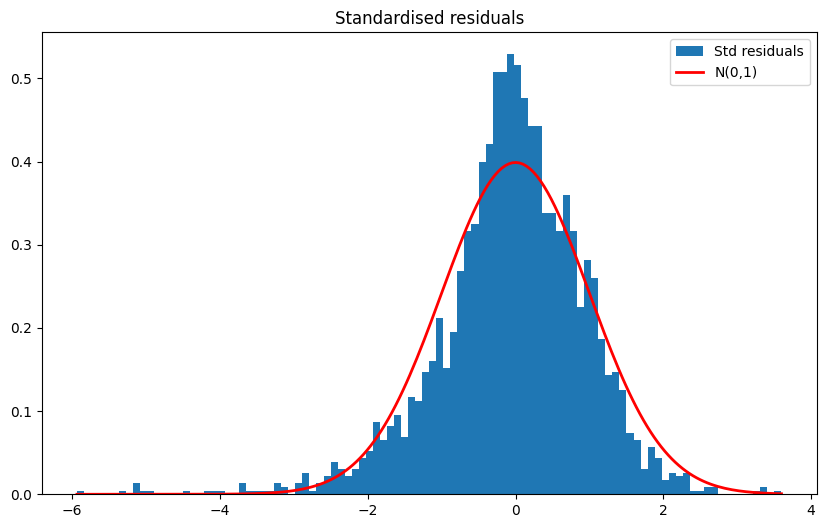

In [46]:
# Distribution of standardised residuals
plt.figure(figsize = (10, 6))
plt.hist(gm_std_resid, bins = 100, density = True, label = "Std residuals")

x = np.linspace(gm_std_resid.min(), gm_std_resid.max(), 200)
plt.plot(x, norm.pdf(x, loc = 0, scale = 1), color = "red", linewidth = 2, label = "N(0,1)")

plt.title("Standardised residuals")
plt.legend()

print("\nDistribution of standardised residuals:\n")
plt.show()

In [108]:
# Test normality formally
# H0: X ~ N in both tests
norm_test = pd.DataFrame({
    "test": ["Shapiro-Wilk", "Jarque-Bera"],
    "stat": [shapiro(gm_std_resid).statistic, jarque_bera(gm_std_resid).statistic],
    "pval": [shapiro(gm_std_resid).pvalue, jarque_bera(gm_std_resid).pvalue]
})
norm_test["p<0.05"] = norm_test["pval"] < 0.05

print("\nTest standardised residuals for normality:\n")
norm_test 


Test standardised residuals for normality:



,test,stat,pval,p<0.05
0,Shapiro-Wilk,0.965547,1.337235e-23,True
1,Jarque-Bera,990.716849,7.388729e-216,True


Formal tests seem to confirm what the graph suggests. Both reject normality. The graph shows us a slight left skew and a number of outliers.

#### Forecast

In [48]:
# Make 5-period ahead forecast
gm_forecast = gm_result.forecast(horizon = 5)

# Print the forecast variance
print("\nVariance forecast:\n")
print(gm_forecast.variance[-1:])


Variance forecast:

           h.1       h.2      h.3       h.4       h.5
2608  0.876879  0.890394  0.90354  0.916326  0.928762


In [49]:
# Extract the forecasted conditional mean
gmfc_mean = gm_forecast.mean

# Extract the forecasted conditional variance (primary output)
gmfc_variance = gm_forecast.variance

## Skewed distribution model

### Fit the model and extract results

In [51]:
# Specify GARCH model assumptions
skewt_gm = arch_model(snp_returns, p = 1, q = 1, mean = "constant", vol = "GARCH", dist = "skewt")

# Fit the model
sk_result = skewt_gm.fit(update_freq = 4)

# Display model fitting summary
print(sk_result.summary())

Iteration:      4,   Func. Count:     40,   Neg. LLF: 3008.700549141471
Iteration:      8,   Func. Count:     73,   Neg. LLF: 3131.4376086270695
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2977.255469660139
            Iterations: 11
            Function evaluations: 97
            Gradient evaluations: 11
                           Constant Mean - GARCH Model Results                           
Dep. Variable:                        log_return   R-squared:                       0.000
Mean Model:                        Constant Mean   Adj. R-squared:                  0.000
Vol Model:                                 GARCH   Log-Likelihood:               -2977.26
Distribution:      Standardized Skew Student's t   AIC:                           5966.51
Method:                       Maximum Likelihood   BIC:                           6001.26
                                                   No. Observations:                 2418
Date:           


Standardised residuals and standard deviation (skewed t model):



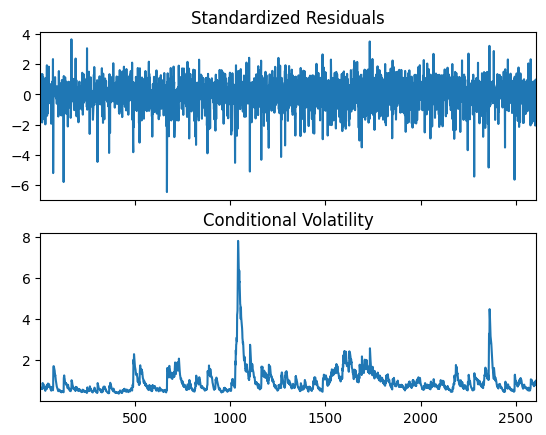

In [53]:
# Plot fitted results
sk_result.plot()

print("\nStandardised residuals and standard deviation (skewed t model):\n")
plt.show()

### Compare volatility


Compare normal and skewed t volatility:



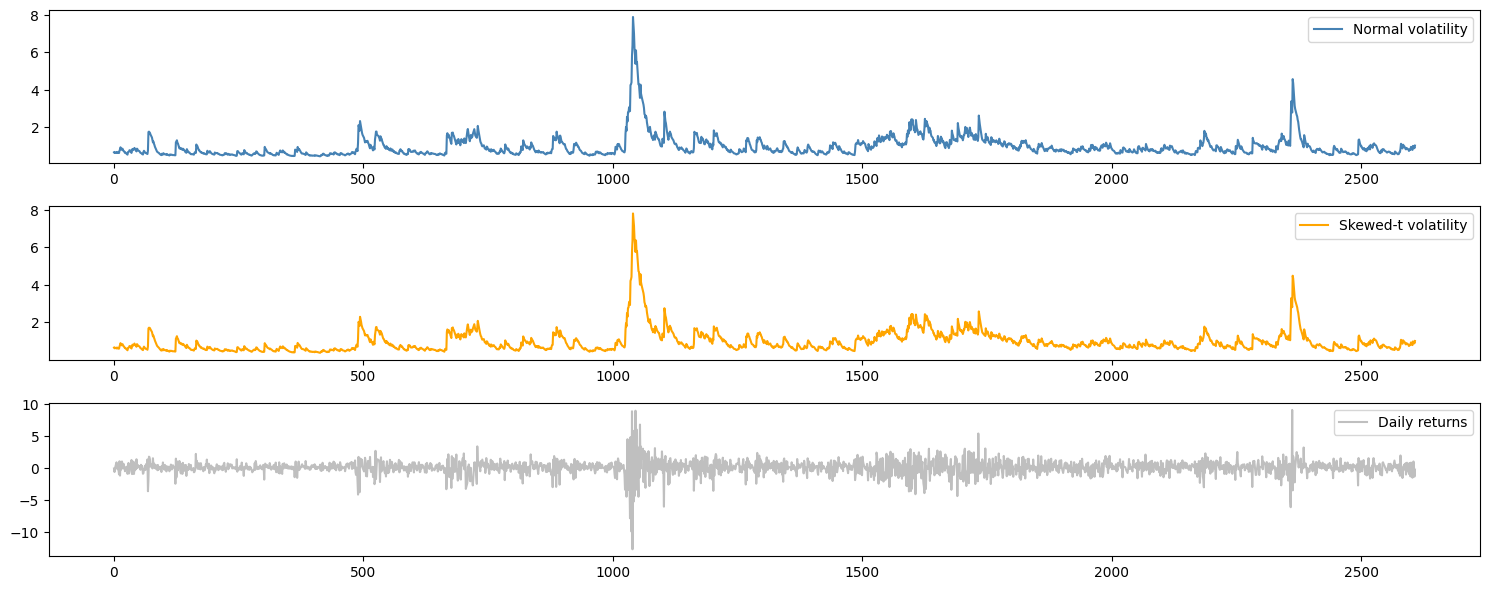

In [63]:
# Get model estimated volatility
sk_std_dev = sk_result.conditional_volatility

# Plot model fitting results
#plt.figure(figsize = (10, 6))
#plt.plot(sk_std_dev, color = "gold", label = "Skewed-t volatility")
#plt.plot(gm_std_dev, color = "red", label = "Normal volatility")
#plt.plot(snp_returns, color = "grey", label = "Daily returns", alpha = 0.2)
#plt.legend(loc = "upper right")

fig, axes = plt.subplots(3, 1, figsize = (15, 6))

axes[0].plot(gm_std_dev, color = "steelblue", label = "Normal volatility")
axes[0].legend(loc = "upper right")
axes[1].plot(sk_std_dev, color = "orange", label = "Skewed-t volatility")
axes[1].legend(loc = "upper right")
axes[2].plot(snp_returns, color = "grey", label = "Daily returns", alpha = 0.5)
axes[2].legend(loc = "upper right")

print("\nCompare normal and skewed t volatility:\n")
plt.tight_layout()
plt.show()

### Inspect residuals


Compare normal and skewed t standardised residuals:



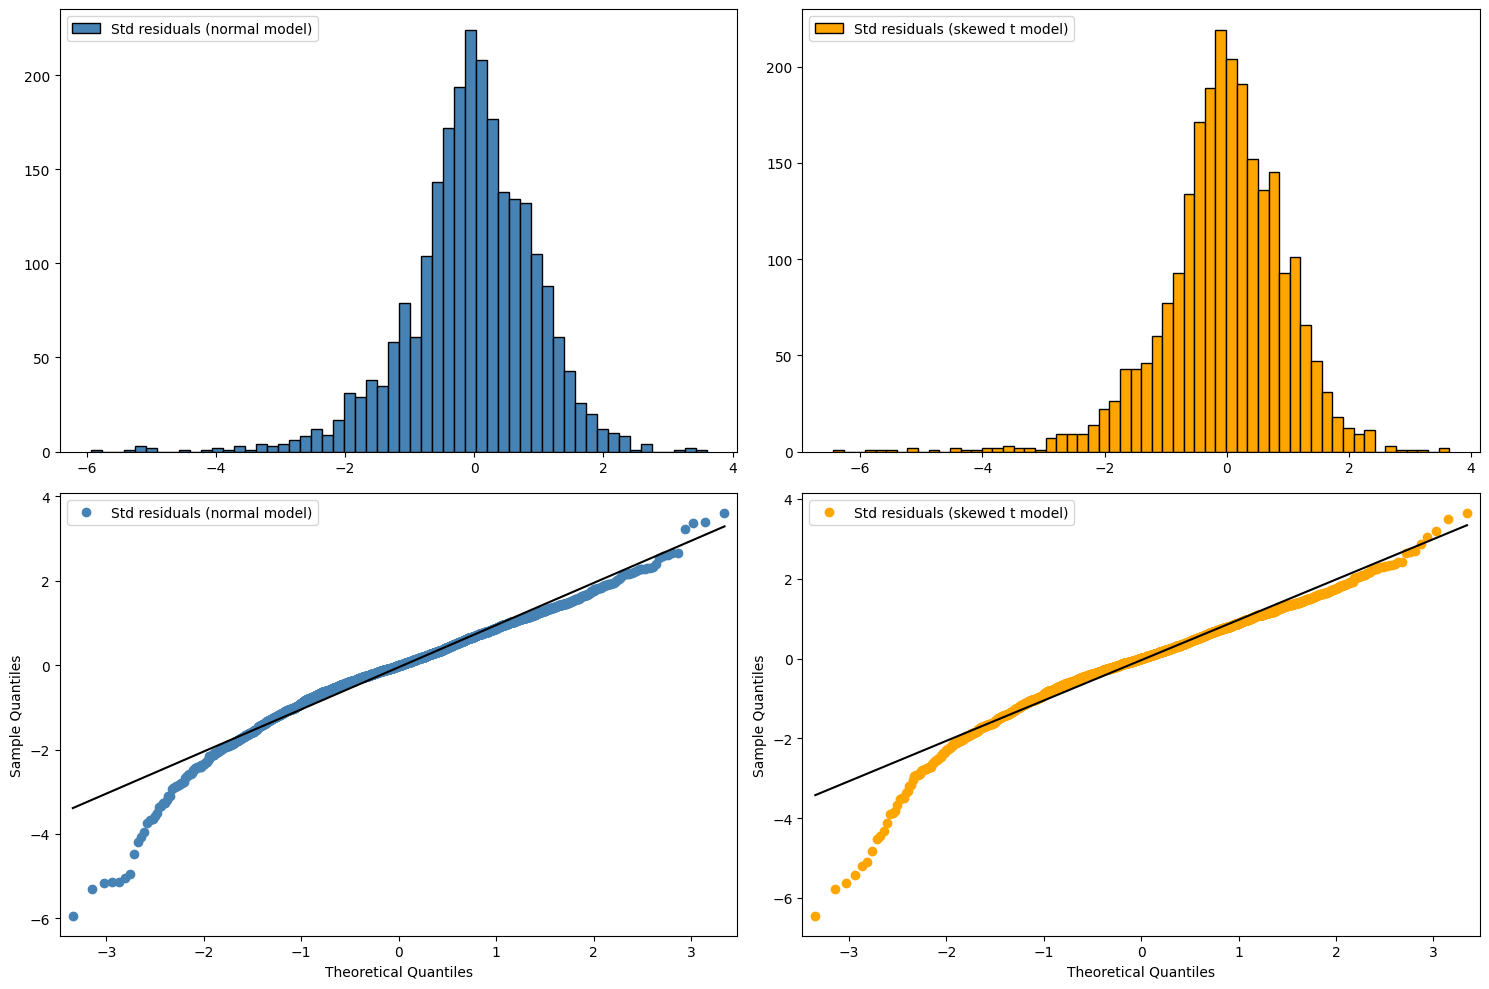

In [88]:
# Extract the standardised residuals
sk_std_resid = sk_result.std_resid

fig, axes = plt.subplots(2, 2, figsize = (15, 10))

axes[0, 0].hist(gm_std_resid, bins = fd_bins(gm_std_resid), color = "steelblue", edgecolor = "black", label = "Std residuals (normal model)")
axes[0, 0].legend(loc = "upper left")
axes[0, 1].hist(sk_std_resid, bins = fd_bins(sk_std_resid), color = "orange", edgecolor = "black", label = "Std residuals (skewed t model)")
axes[0, 1].legend(loc = "upper left")

qqplot(
    gm_std_resid, line = "s", ax = axes[1, 0], 
    markerfacecolor = "steelblue", 
    markeredgecolor = "steelblue",
    label = "Std residuals (normal model)"
)
axes[1, 0].legend(loc = "upper left")
axes[1, 0].get_lines()[1].set_color("black")
qqplot(
    sk_std_resid, line = "s", ax = axes[1, 1], 
    markerfacecolor = "orange", markeredgecolor = "orange", 
    label = "Std residuals (skewed t model)"
)
axes[1, 1].legend(loc = "upper left")
axes[1, 1].get_lines()[1].set_color("black")

print("\nCompare normal and skewed t standardised residuals:\n")
plt.tight_layout()
plt.show()

There is, perhaps, a perceptible improvement to the smoothness of the QQ curve in the skewed t model.

### Compare the models

In [115]:
# Likelihood ratio test
# H0: normal model sufficient
ell_normal = gm_result.loglikelihood
ell_skewt  = sk_result.loglikelihood

lr_stat = 2 * (ell_skewt - ell_normal)
p_value = chi2.sf(lr_stat, df = 2)

# Log likelihood, AIC, BIC
model_comparison = pd.DataFrame({
    "model": ["normal", "skewed t"],
    "log_lik": [gm_result.loglikelihood, sk_result.loglikelihood],
    "AIC": [gm_result.aic, sk_result.aic],
    "BIC": [gm_result.bic, sk_result.bic]
})

print("\nModel comparison:\n")
print(model_comparison)
print("\nLikelihood ratio test:\n")
print(f"Statistic: {lr_stat:.2f}\np-value: {p_value:.4e}\np<0.05: {p_value < 0.05}")



Model comparison:

      model      log_lik          AIC          BIC
0    normal -3085.293383  6178.586765  6201.749549
1  skewed t -2977.255470  5966.510939  6001.255116

Likelihood ratio test:

Statistic: 216.08
p-value: 1.2015e-47
p<0.05: True


AIC, BIC and the log-likelihood test all indicate that the skewed t model is a better fit.

## Constant and AR mean models

In [117]:
# Specify GARCH model assumptions
norm_ar_gm = arch_model(snp_returns, p = 1, q = 1, mean = "AR", vol = "GARCH", dist = "normal")

# Fit the model
armean_result = norm_ar_gm.fit(update_freq = 4)

# Constant mean model
cmean_result = gm_result

Iteration:      4,   Func. Count:     33,   Neg. LLF: 3282.50123533948
Iteration:      8,   Func. Count:     56,   Neg. LLF: 3085.2985155153765
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3085.293382640665
            Iterations: 11
            Function evaluations: 70
            Gradient evaluations: 11


In [120]:
print("\nNormal model with a constant mean:\n")
print(cmean_result.summary())


Normal model with a constant mean:

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3085.29
Distribution:                  Normal   AIC:                           6178.59
Method:            Maximum Likelihood   BIC:                           6201.75
                                        No. Observations:                 2418
Date:                Fri, Mar 20 2026   Df Residuals:                     2417
Time:                        10:12:40   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0876  1.49

In [121]:
print("\nNormal model with an AR mean:\n")
print(armean_result.summary())


Normal model with an AR mean:

                           AR - GARCH Model Results                           
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3085.29
Distribution:                  Normal   AIC:                           6178.59
Method:            Maximum Likelihood   BIC:                           6201.75
                                        No. Observations:                 2418
Date:                Fri, Mar 20 2026   Df Residuals:                     2417
Time:                        12:43:28   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
Const          0.0876  1.493e-02


Correlation coefficient:

0.9999999999999998

Compare constant mean and AR mean volatility:



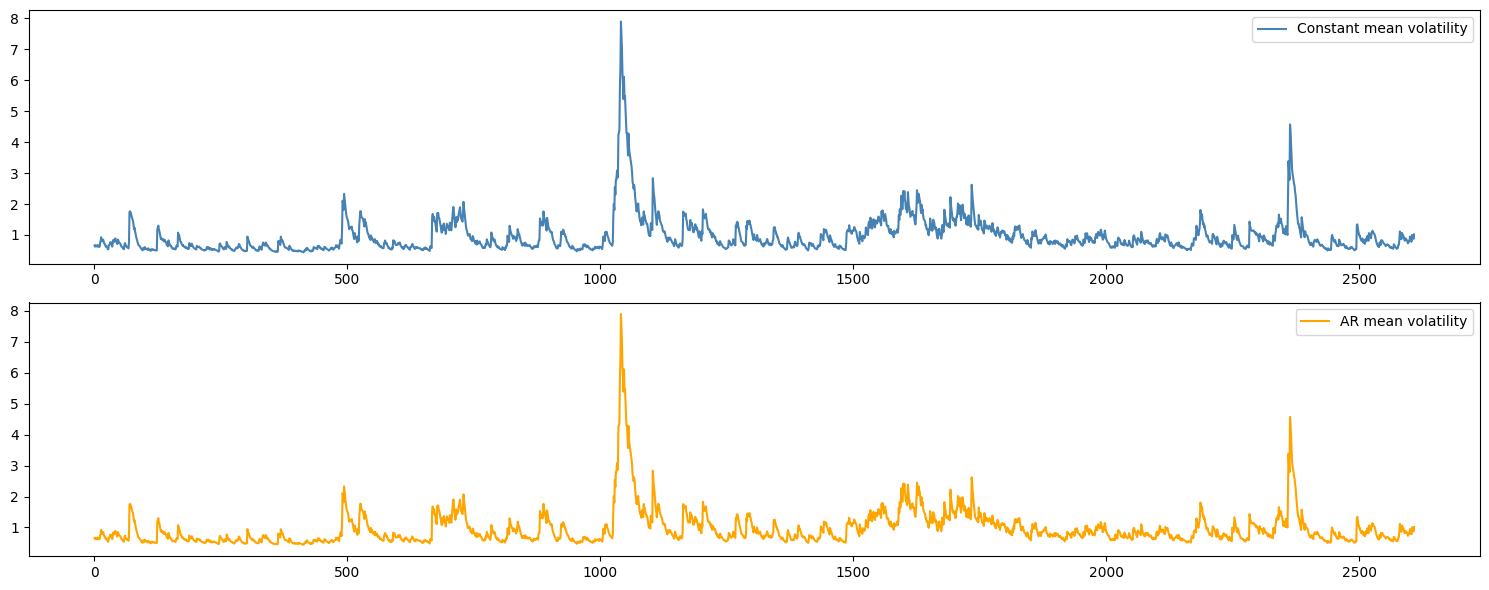

In [125]:
# Plot model volatility
cmean_vol = cmean_result.conditional_volatility
armean_vol = armean_result.conditional_volatility

# Check correlation of volatility estimations
print("\nCorrelation coefficient:\n")
print(np.corrcoef(cmean_vol, armean_vol)[0,1])

#plt.figure(figsize = (10, 6))
#plt.plot(cmean_vol, color = "steelblue", label = "Constant mean volatility")
#plt.plot(armean_vol, color = "orange", label = "AR mean volatility")
#plt.legend(loc = "upper right")
#plt.show()

fig, axes = plt.subplots(2, 1, figsize = (15, 6))

axes[0].plot(cmean_vol, color = "steelblue", label = "Constant mean volatility")
axes[0].legend(loc = "upper right")
axes[1].plot(armean_vol, color = "orange", label = "AR mean volatility")
axes[1].legend(loc = "upper right")

print("\nCompare constant mean and AR mean volatility:\n")
plt.tight_layout()

Modelling volatility with constant and AR mean fetches apparently indistinguishable results with a near perfect correlation. The graphs agree with the summary readouts, which report identical coefficients. Volatility clustering is driven predominantly by the error.

## GJR-GARCH and EGARCH models

In [128]:
# Fit the GJR-GARCH
gjrgm_gm = arch_model(snp_returns, p = 1, q = 1, o = 1, mean = "constant", vol = "GARCH", dist = "skewt")
gjrgm_result = gjrgm_gm.fit(update_freq = 5)
gjrgm_vol = gjrgm_result.conditional_volatility

# Fit the EGARCH
egarch_gm = arch_model(snp_returns, p = 1, q = 1, o = 1, mean = "constant", vol = "EGARCH", dist = "skewt")
egarch_result = egarch_gm.fit(update_freq = 5)
egarch_vol = egarch_result.conditional_volatility

Iteration:      5,   Func. Count:     50,   Neg. LLF: 51308.553105778
Iteration:     10,   Func. Count:     96,   Neg. LLF: 2945.156148897643
Iteration:     15,   Func. Count:    140,   Neg. LLF: 2941.1043465763087
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2941.1043465763087
            Iterations: 16
            Function evaluations: 147
            Gradient evaluations: 16
Iteration:      5,   Func. Count:     57,   Neg. LLF: 144986.1581441164
Iteration:     10,   Func. Count:    103,   Neg. LLF: 2930.7090603240354
Iteration:     15,   Func. Count:    142,   Neg. LLF: 2930.652192488896
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2930.6521924887875
            Iterations: 15
            Function evaluations: 142
            Gradient evaluations: 15



S&P500 returns, GJR-GARCH and EGARCH estimated volatility:



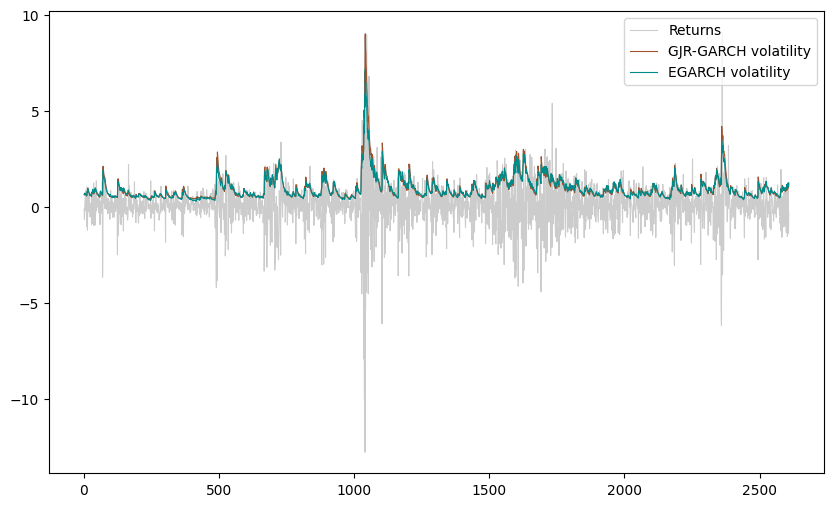

In [134]:
plt.figure(figsize = (10, 6))
# Plot the returns
plt.plot(snp_returns, linewidth = 0.8, color = "grey", alpha = 0.4, label = "Returns")

# Plot GJR-GARCH estimated volatility
plt.plot(gjrgm_vol, linewidth = 0.8, color = "sienna", label = "GJR-GARCH volatility")

# Plot EGARCH  estimated volatility
plt.plot(egarch_vol, linewidth = 0.8, color = "darkcyan", label = "EGARCH volatility")

plt.legend(loc = "upper right")

print("\nS&P500 returns, GJR-GARCH and EGARCH estimated volatility:\n")
plt.show()

## Rolling window forecast

- too wide a window may result in higher variance
- too narrow a window may result in a higher bias
- optimal window size balances the trade-off between bias and variance

``` Python
# Expanding window
for i in range(120):
	gm_result = basic_gm.fit(
		first_obs = start_loc,
		last_obs = i + end_loc,
		disp = "off"
	)
	temp_result = gmresult.forecast(horizon = 1).variance

# Fixed rolling window
for i in range(120):
	gm_result = basic_gm.fit(
		first_obs = i + start_loc,
		last_obs = i + end_loc,
		disp = "off"
	)
	temp_result = gm_result.forecast(horizon = 1).variance
```